# Ensemble Learning
- Demonstrates Bagging, Random Forest, Boosting and Stacking.
- Dataset: Breast Cancer (sklearn)


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X.shape)

(569, 30)


## Baseline Model – Decision Tree

In [2]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test,pred_dt)
print('Decision Tree Accuracy:',acc_dt)

Decision Tree Accuracy: 0.9473684210526315


## Bagging using KNN

In [3]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

bag_knn = BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=50, random_state=42)

bag_knn.fit(X_train,y_train)
pred_bag_knn = bag_knn.predict(X_test)

acc_bag_knn = accuracy_score(y_test,pred_bag_knn)
print('Bagging KNN Accuracy:',acc_bag_knn)

Bagging KNN Accuracy: 0.9473684210526315


## Random Forest (Bagging based Ensemble)

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test,pred_rf)
print('Random Forest Accuracy:',acc_rf)

Random Forest Accuracy: 0.9649122807017544


## Boosting using AdaBoost

In [5]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train,y_train)

pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test,pred_ada)
print('AdaBoost Accuracy:',acc_ada)

AdaBoost Accuracy: 0.9736842105263158


## Stacking Ensemble

In [6]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

estimators=[('dt',DecisionTreeClassifier()),('knn',KNeighborsClassifier())]

stack=StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

stack.fit(X_train,y_train)
pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test,pred_stack)
print('Stacking Accuracy:',acc_stack)

Stacking Accuracy: 0.9736842105263158


## Accuracy Comparison

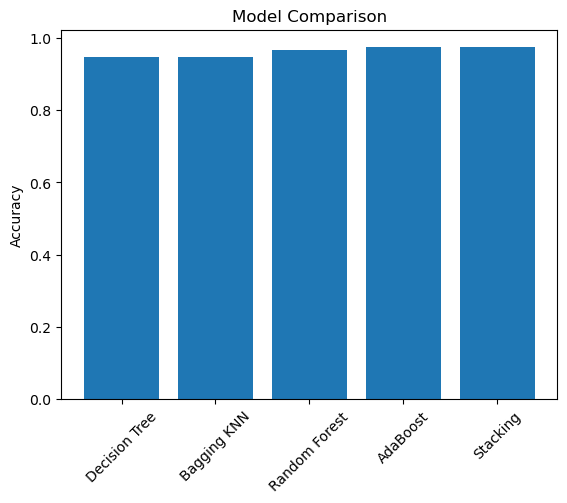

In [7]:
import matplotlib.pyplot as plt

models=['Decision Tree','Bagging KNN','Random Forest','AdaBoost','Stacking']
scores=[acc_dt,acc_bag_knn,acc_rf,acc_ada,acc_stack]

plt.bar(models,scores)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(rotation=45)
plt.show()